In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score  # классы несбалансированы
from sklearn.metrics import average_precision_score  # положительный класс -- редкий
from sklearn.metrics import balanced_accuracy_score  # accuracy для дисбаланса
from sklearn.metrics import f1_score

In [2]:
DATA_DIR = Path('./ml-project-adaai_VK_predict_hackaton/data')

train_path = DATA_DIR / 'train.csv'
test_path = DATA_DIR / 'test.csv'
submit_path = DATA_DIR / 'submit.csv'

for path in [train_path, test_path, submit_path]:
    print(f'{path}:', 'OK' if path.exists() else 'NOT FOUND')


ml-project-adaai_VK_predict_hackaton/data/train.csv: OK
ml-project-adaai_VK_predict_hackaton/data/test.csv: OK
ml-project-adaai_VK_predict_hackaton/data/submit.csv: OK


In [3]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submit_df = pd.read_csv(submit_path)

df = train_df.copy()

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
print('submit shape:', submit_df.shape)


train shape: (247972, 1369)
test shape: (106274, 1368)
submit shape: (106274, 2)


In [4]:
df.head()


,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,239134,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,1,1,1,1,1,0
1,234708,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,1.0,...,-1.0,-1.0,-1.0,1,1,1,1,0,0,1
2,268300,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,4.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,283077,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,337271,1.0,0.5,0.5,1.0,1.0,1.0,9.0,1.0,1.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 247972 entries, 0 to 247971
Columns: 1369 entries, index to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 2.5 GB


In [6]:
df.describe()


,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
count,247972.000000,247972.000000,247972.0,247972.0,247972.0,247972.0,247972.000000,247972.000000,247972.000000,247972.000000,...,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000
mean,177081.186364,0.013493,0.5,0.5,1.0,1.0,0.794473,1.864892,1.270490,1.457911,...,-0.143246,-0.145520,-0.149049,0.121848,0.136741,0.096204,0.034742,0.139403,0.190792,0.149783
std,102245.504744,0.115375,0.0,0.0,0.0,0.0,0.715883,1.802944,0.919966,1.622873,...,0.368512,0.364513,0.358193,0.327111,0.343575,0.294872,0.183126,0.346367,0.392926,0.356859
min,2.000000,0.000000,0.5,0.5,1.0,1.0,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,88544.750000,0.000000,0.5,0.5,1.0,1.0,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,177110.500000,0.000000,0.5,0.5,1.0,1.0,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,265596.750000,0.000000,0.5,0.5,1.0,1.0,1.000000,3.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,354243.000000,1.000000,0.5,0.5,1.0,1.0,13.000000,30.000000,23.000000,31.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
test_df.head()


,index,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,194357,0.5,0.5,1.0,1.0,1.0,1.0,1.0,3.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,313222,0.5,0.5,1.0,1.0,0.0,2.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,321873,0.5,0.5,1.0,1.0,0.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1,0,0,0,0,0,0
3,118689,0.5,0.5,1.0,1.0,1.0,3.0,2.0,3.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,342561,0.5,0.5,1.0,1.0,0.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [8]:
submit_df.head()


,index,score
0,194357,0.051267
1,313222,0.428752
2,321873,0.787954
3,118689,0.621100
4,342561,0.518860


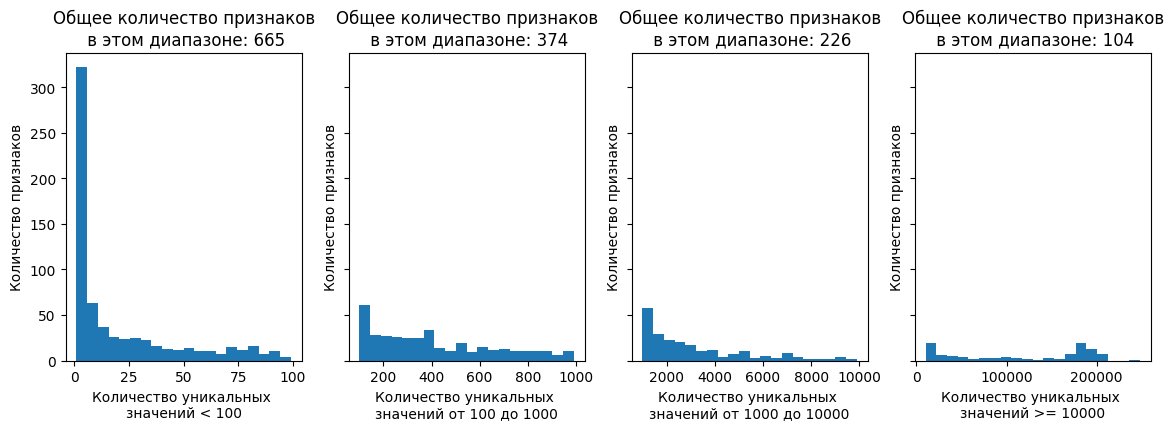

In [9]:
uniq_values = {col: df[col].unique() for col in df.columns}

num_of_unique_values = np.array([len(df[col].unique()) for col in df.columns])

fig, ax = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

num_of_uniq_filt = num_of_unique_values[num_of_unique_values < 100]
ax[0].hist(list(num_of_uniq_filt), bins=20)
ax[0].set_xlabel('Количество уникальных \nзначений < 100')
ax[0].set_ylabel('Количество признаков')
ax[0].set_title('Общее количество признаков\n в этом диапазоне: ' + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 100) & (num_of_unique_values < 1000)]
ax[1].hist(list(num_of_uniq_filt), bins=20)
ax[1].set_xlabel('Количество уникальных \nзначений от 100 до 1000')
ax[1].set_ylabel('Количество признаков')
ax[1].set_title('Общее количество признаков\n в этом диапазоне: ' + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 1000) & (num_of_unique_values < 10000)]
ax[2].hist(list(num_of_uniq_filt), bins=20)
ax[2].set_xlabel('Количество уникальных \nзначений от 1000 до 10000')
ax[2].set_ylabel('Количество признаков')
ax[2].set_title('Общее количество признаков\n в этом диапазоне: ' + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[num_of_unique_values >= 10000]
ax[3].hist(list(num_of_uniq_filt), bins=20)
ax[3].set_xlabel('Количество уникальных \nзначений >= 10000')
ax[3].set_ylabel('Количество признаков')
ax[3].set_title('Общее количество признаков\n в этом диапазоне: ' + str(len(num_of_uniq_filt)))

plt.show()
None


In [10]:
train_df = train_df.drop_duplicates()
train_df.dropna()

for col in train_df.columns:
    if len(train_df.loc[:, col].unique()) < 2:
        print("dropped", col)

        train_df = train_df.drop(columns=[col])


dropped feature_0
dropped feature_1
dropped feature_2
dropped feature_3
dropped feature_49
dropped feature_1057
dropped feature_1064


In [11]:
train_df.shape, train_df.head()

((247972, 1362),
     index  target  feature_4  feature_5  feature_6  feature_7  feature_8  \
 0  239134     0.0        0.0        0.0        0.0        0.0        1.0   
 1  234708     0.0        0.0        0.0        0.0        1.0        0.0   
 2  268300     0.0        1.0        3.0        1.0        4.0        0.0   
 3  283077     0.0        1.0        3.0        1.0        0.0        3.0   
 4  337271     1.0        1.0        9.0        1.0        1.0        3.0   
 
    feature_9  feature_10  feature_11  ...  feature_1357  feature_1358  \
 0        1.0    0.680302    0.767927  ...           0.0           0.0   
 1        1.0    0.680302    0.767927  ...          -1.0          -1.0   
 2        9.0    0.794758    2.471037  ...           0.0           0.0   
 3        8.0    0.917668    0.558128  ...           0.0           0.0   
 4       15.0    0.698426    1.205527  ...           0.0           0.0   
 
    feature_1359  feature_1360  feature_1361  feature_1362  feature_1363 

In [12]:
X_ = train_df.drop(columns=["index", "target"])
y_ = train_df.loc[:, "target"]

X_train, X_test, y_train, y_test = train_test_split(X_, y_, test_size=0.3, random_state=42)

X_train.shape, y_train.shape, X_test, y_test

((173580, 1360),
 (173580,),
         feature_4  feature_5  feature_6  feature_7  feature_8  feature_9  \
 189058        1.0        1.0        1.0        1.0        0.0        4.0   
 223521        1.0        2.0        1.0        3.0        0.0        7.0   
 213142        1.0        2.0        1.0        2.0        1.0        7.0   
 176244        0.0        1.0        0.0        1.0        0.0        2.0   
 34065         1.0        3.0        1.0        4.0        0.0        9.0   
 ...           ...        ...        ...        ...        ...        ...   
 14912         1.0        2.0        1.0        1.0        0.0        5.0   
 48416         1.0        2.0        1.0        1.0        0.0        5.0   
 191345        0.0        0.0        1.0        2.0        0.0        3.0   
 194383        0.0        2.0        1.0        2.0        0.0        5.0   
 22079         1.0        1.0        0.0        0.0        0.0        2.0   
 
         feature_10  feature_11  feature_12  

In [13]:
zeros_count = len(y_train[y_train==0])
ones_count = len(y_train[y_train==1])
total = len(y_train)

print(zeros_count / total)


0.9864327687521603


Крайне много нулей, классы несбалансированы

In [14]:
def count_metrics(y_test, y_pred, y_score):
    """
    roc_auc_score: вероятность того, что модель присвоит случайному объекту класса 1 более высокий score, чем случайному объекту класса 0; чем ближе к 1, тем лучше разделение классов, 0.5 — уровень случайного угадывания.

    average_precision_score: среднее качество поиска объектов класса 1 по всем возможным порогам; высокая метрика означает, что среди объектов, которые модель считает наиболее похожими на класс 1, действительно много единиц.

    balanced_accuracy_score: средняя точность отдельно по классу 0 и по классу 1; полезна при дисбалансе классов, потому что не дает модели выглядеть хорошей только за счет угадывания самого частого класса.

    f1_score: одна итоговая оценка качества предсказания класса 1, которая будет высокой только тогда, когда модель одновременно находит много настоящих единиц и не слишком часто ошибочно объявляет нули единицами.
    """
    
    print("roc auc:", roc_auc_score(y_test, y_score))
    print("average precision:", average_precision_score(y_test, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
    print("f1:", f1_score(y_test, y_pred))
    

### Предсказание нулем

In [15]:
y_pred_zeros = np.zeros(y_test.shape)


In [16]:
count_metrics(y_test, y_pred_zeros, y_pred_zeros)

roc auc: 0.5
average precision: 0.013321324873642328
balanced accuracy: 0.5
f1: 0.0


### Предсказание схожим с `train` распределением

In [17]:
rng = np.random.default_rng(42)

p_one = ones_count / total
p_zero = zeros_count / total

y_pred_random = rng.choice(
    [0, 1],
    size=y_test.shape[0],
    p=[p_zero, p_one]
)

In [18]:
count_metrics(y_test, y_pred_random, y_pred_random)

roc auc: 0.5002380520610619
average precision: 0.0133277979690972
balanced accuracy: 0.5002380520610619
f1: 0.013951170901843548


### Logistic Regression

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
logreg = LogisticRegression(
    C=1.0,
    solver="saga",
    class_weight="balanced",
    max_iter=100_000,
    tol=1e-3,
    random_state=42,
    verbose=1,
)

logreg.fit(X_train_scaled, y_train)


Epoch 1, change: 1
Epoch 2, change: 0.3317478
Epoch 3, change: 0.14167068
Epoch 4, change: 0.11904875
Epoch 5, change: 0.35709721
Epoch 6, change: 0.22011977
Epoch 7, change: 0.22642255
Epoch 8, change: 0.18892096
Epoch 9, change: 0.072462449
Epoch 10, change: 0.062154039
Epoch 11, change: 0.054118661
Epoch 12, change: 0.047957041
Epoch 13, change: 0.043401974
Epoch 14, change: 0.038751265
Epoch 15, change: 0.03550446
Epoch 16, change: 0.032123626
Epoch 17, change: 0.029535191
Epoch 18, change: 0.027285562
Epoch 19, change: 0.025707435
Epoch 20, change: 0.024231873
Epoch 21, change: 0.022853618
Epoch 22, change: 0.021503591
Epoch 23, change: 0.020407284
Epoch 24, change: 0.01928281
Epoch 25, change: 0.018312464
Epoch 26, change: 0.017432015
Epoch 27, change: 0.01664102
Epoch 28, change: 0.01574562
Epoch 29, change: 0.01505004
Epoch 30, change: 0.014359344
Epoch 31, change: 0.013751717
Epoch 32, change: 0.013101762
Epoch 33, change: 0.012569066
Epoch 34, change: 0.012001681
Epoch 35, ch

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [21]:
y_pred_lr = logreg.predict(X_test_scaled)
y_score_lr = logreg.predict_proba(X_test_scaled)[:, 1]

len(y_pred_lr[y_pred_lr==0]), zeros_count * 0.3

(47242, 51367.5)

In [22]:
count_metrics(y_test, y_pred_lr, y_score_lr)

roc auc: 0.6215888295128906
average precision: 0.021319979654042163
balanced accuracy: 0.589653449896908
f1: 0.03816495504779503


### Random Forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=1_000,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 422 tasks      | elapsed:   29.6s
[Parallel(n_jobs=-1)]: Done 772 tasks      | elapsed:   54.9s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.2min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [24]:
y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]

len(y_pred_rf[y_pred_rf==0]), zeros_count * 0.3

[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.2s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:    0.4s
[Parallel(n_jobs=14)]: Done 772 tasks      | elapsed:    0.8s
[Parallel(n_jobs=14)]: Done 1000 out of 1000 | elapsed:    1.0s finished
[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.2s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:    0.4s
[Parallel(n_jobs=14)]: Done 772 tasks      | elapsed:    0.8s
[Parallel(n_jobs=14)]: Done 1000 out of 1000 | elapsed:    1.0s finished


(74115, 51367.5)

In [25]:
count_metrics(y_test, y_pred_rf, y_score_rf)

roc auc: 0.6406441161417458
average precision: 0.07010001620847725
balanced accuracy: 0.5282829178083467
f1: 0.09305993690851735


Лес показал себя по метрикам лучше остальных моделей. 

В частности, у него лучший `ROG_AUC`. Его обучение заняло в $6$-$7$ раз меньше времени, чем логрега.